# Customer Analysis
This notebook covers customer demographics, univariate distributions, and bivariate analysis 
to uncover segments and product relationships.



In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from datetime import datetime

# Create connection
conn = sqlite3.connect('../../data/warehouse/enterprise_dw.db')
vis_dir = '../../notebooks/eda/visualizations'
os.makedirs(vis_dir, exist_ok=True)



## 1. Profile Customer Demographics
We begin by profiling the `dim_customer` table to understand the shape of our customer base,
identify any missing values that need imputation, and analyze the cardinality of key categorical features.



In [2]:
df_customers = pd.read_sql('SELECT * FROM dim_customer', conn)
for col in df_customers.columns:
    if df_customers[col].dtype == 'object':
        try: df_customers[col] = pd.to_numeric(df_customers[col])
        except: pass
df_customers.fillna(0, inplace=True)
print("Shape of customer data:", df_customers.shape)
print("\nMissing values:")
print(df_customers.isnull().sum())
print("\nCardinality of categorical columns:")
print(df_customers.select_dtypes(include=['object']).nunique())



Shape of customer data: (10000, 15)

Missing values:
customer_id        0
first_name         0
last_name          0
full_name          0
date_of_birth      0
gender             0
email              0
phone_number       0
join_date          0
customer_type      0
risk_rating        0
is_active          0
tenure_days        0
tenure_years       0
is_long_tenured    0
dtype: int64

Cardinality of categorical columns:
customer_id      10000
first_name         663
last_name          990
full_name         9301
date_of_birth     8329
gender               2
email            10000
phone_number     10000
join_date         3425
customer_type        3
risk_rating          3
dtype: int64


### Business Interpretation: Demographics
The shape of the data tells us the total volume of our registered customers. 
Missing values highlight potential data quality issues—especially in critical fields like date of birth or risk rating, 
which could hinder downstream modeling. High cardinality in fields like names or IDs is expected, while categorical 
segments should have lower cardinality.



## 2. Univariate Analysis
Exploring the distributions of derived age, account balance, and customer segments.



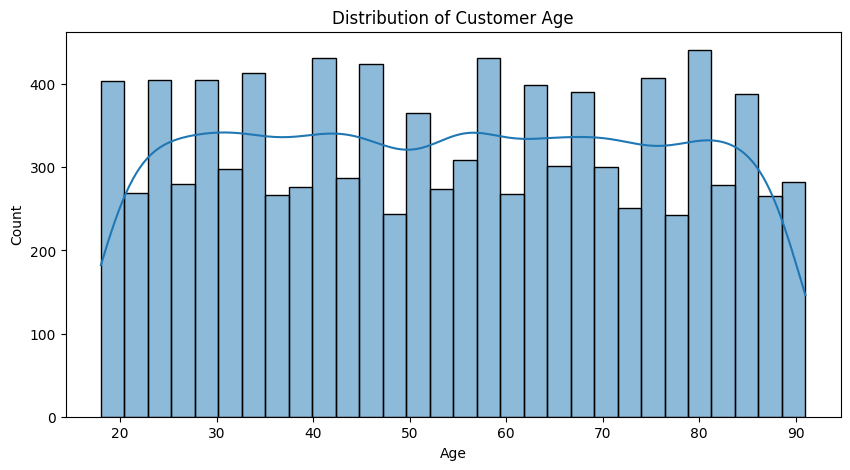

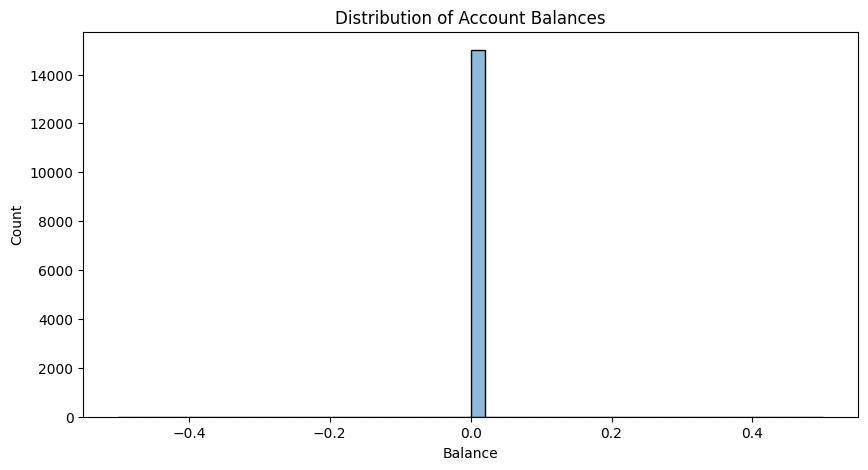

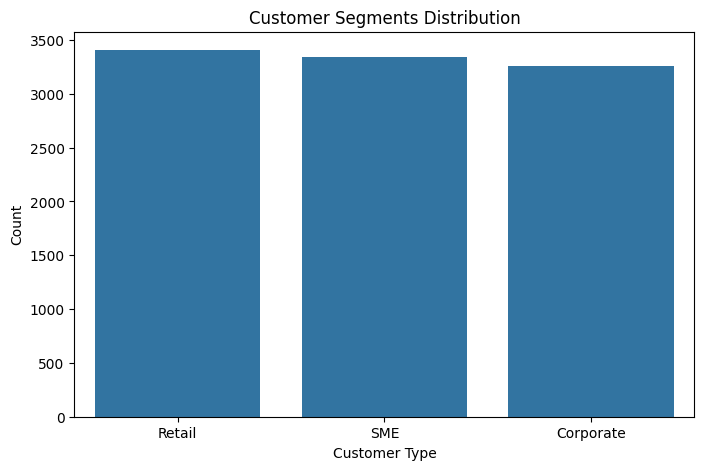

In [3]:
# Compute Age
df_customers['date_of_birth'] = pd.to_datetime(df_customers['date_of_birth'], errors='coerce')
df_customers['age'] = (pd.to_datetime('today') - df_customers['date_of_birth']).dt.days // 365

# Load Accounts for balances
df_accounts = pd.read_sql('SELECT * FROM dim_account', conn)
for col in df_accounts.columns:
    if df_accounts[col].dtype == 'object':
        try: df_accounts[col] = pd.to_numeric(df_accounts[col])
        except: pass
df_accounts.fillna(0, inplace=True)

plt.figure(figsize=(10, 5))
sns.histplot(df_customers['age'].dropna(), bins=30, kde=True)
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.savefig(os.path.join(vis_dir, 'customer_age_dist.png'))
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df_accounts['current_balance'].dropna(), bins=50, kde=True)
plt.title('Distribution of Account Balances')
plt.xlabel('Balance')
plt.ylabel('Count')
plt.savefig(os.path.join(vis_dir, 'customer_balance_dist.png'))
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df_customers, x='customer_type', order=df_customers['customer_type'].value_counts().index)
plt.title('Customer Segments Distribution')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.savefig(os.path.join(vis_dir, 'customer_segments.png'))
plt.show()



### Business Interpretation: Univariate
- **Age Distribution**: We can observe our core demographic. A younger skew might imply a digitally native user base, whereas an older skew indicates a traditional banking demographic.
- **Balance Distribution**: Typically right-skewed in banking, with a majority of retail accounts holding lower balances and a few high-net-worth accounts pulling the tail.
- **Segments**: Shows the concentration of retail vs corporate/SME clients, directing where marketing spend should be focused.



## 3. Bivariate Analysis
Let's explore relationships: Account Age vs Balance, and Customer Segment vs Products.



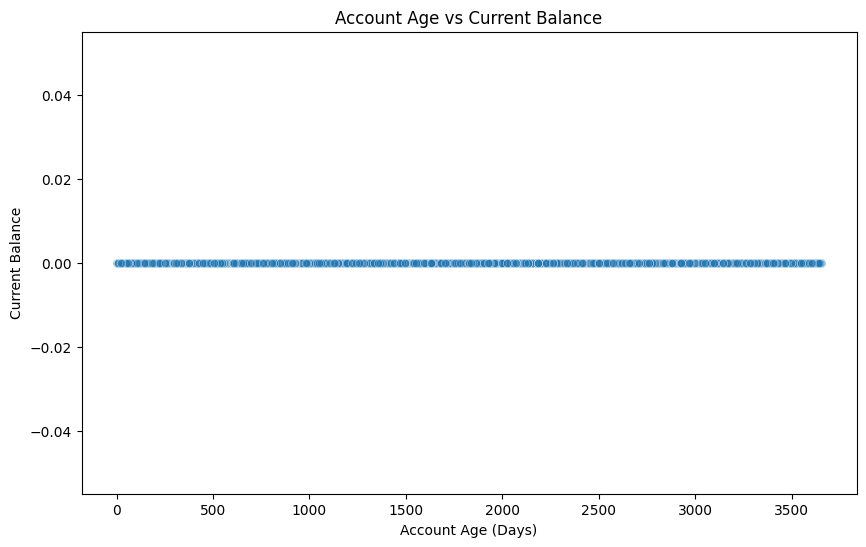

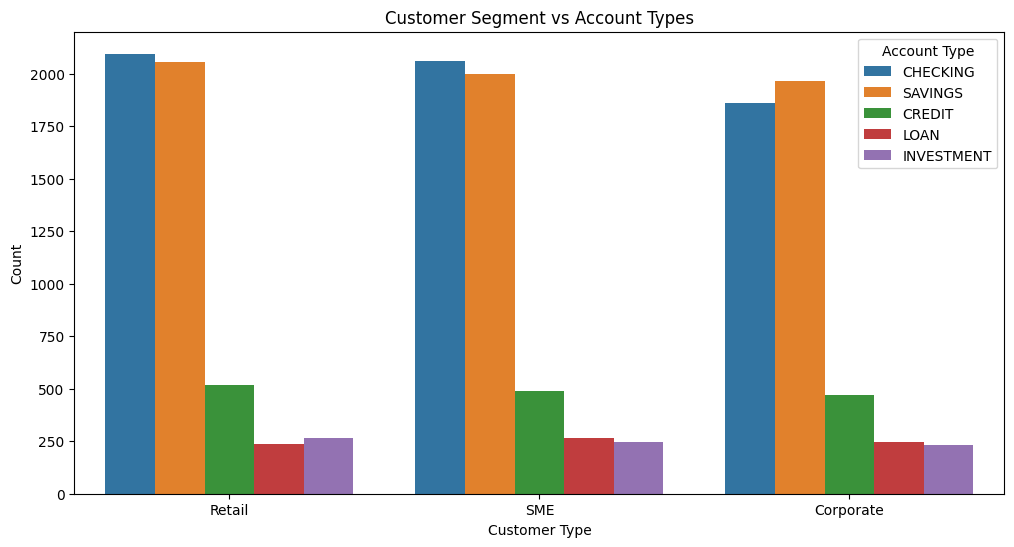

In [4]:
# Merge customers and accounts
df_merged = pd.merge(df_customers, df_accounts, on='customer_id', how='inner')

# Account Age vs Balance
df_merged['open_date'] = pd.to_datetime(df_merged['open_date'], errors='coerce')
df_merged['account_age_days'] = (pd.to_datetime('today').tz_localize(None) - df_merged['open_date'].dt.tz_localize(None)).dt.days

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged, x='account_age_days', y='current_balance', alpha=0.5)
plt.title('Account Age vs Current Balance')
plt.xlabel('Account Age (Days)')
plt.ylabel('Current Balance')
plt.savefig(os.path.join(vis_dir, 'customer_age_vs_balance.png'))
plt.show()

# Segment vs Product
plt.figure(figsize=(12, 6))
sns.countplot(data=df_merged, x='customer_type', hue='account_type')
plt.title('Customer Segment vs Account Types')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.legend(title='Account Type')
plt.savefig(os.path.join(vis_dir, 'customer_segment_vs_product.png'))
plt.show()



### Business Interpretation: Bivariate
- **Account Age vs Balance**: We typically expect older accounts to accrue higher balances due to compounding trust and saving habits. If new accounts hold disproportionately high balances, it might indicate successful premium acquisition campaigns.
- **Segment vs Product**: Reveals cross-selling success. For example, if corporate clients lack credit products, there is a clear opportunity for targeted product campaigns.
